# Visualisation

PyCBA includes a standard matplotlib result plot, individual diagram methods for custom layouts, and an optional Plotly backend for interactive figures. This tutorial collects the main visualisation customisations in one place:

1. re-ordering result panels as **reactions, shear force, bending moment, deflection**;
2. plotting the deflected shape directly on the beam schematic; and
3. using the interactive Plotly backend for result diagrams and moving-load envelopes.

The first two examples use the current public API only, so they are documentation patterns rather than new package features.

In [1]:
import numpy as np
import pycba as cba
import matplotlib.pyplot as plt
from IPython.display import HTML

plt.rcParams["figure.dpi"] = 120

We will use the two-span beam from the introduction.

In [2]:
L = [7.5, 7.0]
EI = 30 * 600e7 * 1e-6  # kNm^2
supports = ["p", "r", "r"]

ba = cba.BeamAnalysis(L, EI, supports=supports)
ba.add_udl(i_member=1, w=20)
ba.add_udl(i_member=2, w=20)
ba.analyze();

## Re-ordering the result panels

The individual matplotlib plotters all accept an existing `ax`. This makes the panel order just a matplotlib layout choice: create the figure, pass the appropriate axis to each `plot_*` method, then add any shared labelling or styling you want.

The method names are:

- `plot_reactions()` for the support reaction diagram;
- `plot_sfd()` for shear force;
- `plot_bmd()` for bending moment; and
- `plot_dsd()` for deflection.

Currently `plot_bmd()` and `plot_sfd()` only shade diagrams when used through `plot_results()`. When passed an existing `ax`, they add just the curve so overlays do not restyle an existing plot. For a fresh custom layout, add the zero line, grid, labels, and the inverted bending-moment axis yourself. If you want the same shaded style, add a normal matplotlib `fill_between()` call on the relevant subplot.

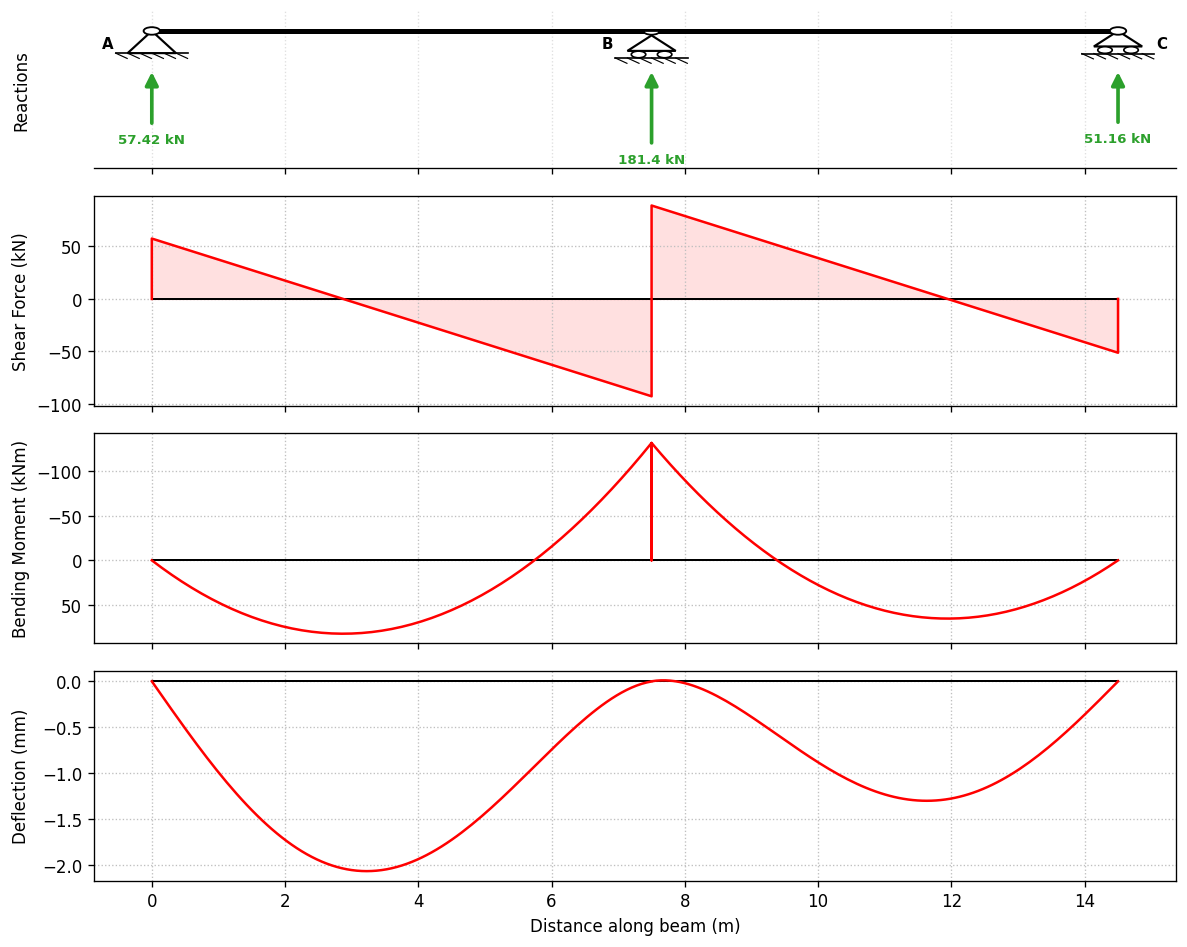

In [3]:
us = cba.get_units()
beam_length = ba.beam.length
res = ba.beam_results.results

fig, axs = plt.subplots(
    4,
    1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [0.75, 1.0, 1.0, 1.0]},
)

# 1. Reactions
ba.plot_reactions(ax=axs[0], show=False)
axs[0].set_xlabel("")
axs[0].set_ylabel("Reactions")

# Common result-diagram formatting for the remaining panels.
for ax in axs[1:]:
    ax.plot([0, beam_length], [0, 0], "k", lw=1.2)
    ax.grid(True, linestyle=":", color="0.75")

# 2. Shear force
ba.plot_sfd(ax=axs[1])
# Because we supplied an existing axis, add shading explicitly if wanted.
axs[1].fill_between(res.x, 0, res.V, color="r", alpha=0.12)
axs[1].set_ylabel(us.shear_axis)

# 3. Bending moment
ba.plot_bmd(ax=axs[2])
axs[2].invert_yaxis()  # sagging-positive convention used by plot_results()
axs[2].set_ylabel(us.moment_axis)

# 4. Deflection
ba.plot_dsd(ax=axs[3])
axs[3].set_ylabel(us.deflection_axis)
axs[3].set_xlabel(us.distance_axis)

fig.align_ylabels(axs)
fig.tight_layout()
plt.show()

## Deflection on the structure schematic

The structure plot is also just a matplotlib axis. Draw the beam first, then get the continuous deflection curve from `beam_results.deflection_curve()` and overlay it.

In the default SI display system the analysis deflection is in metres, while result plots show deflection in millimetres. The beam, supports, and loads remain schematic glyphs, so the overlaid curve usually needs an explicit visual scale factor. Here the deflection curve is scaled down so it sits below the support height; the legend and y-axis state that scale factor.

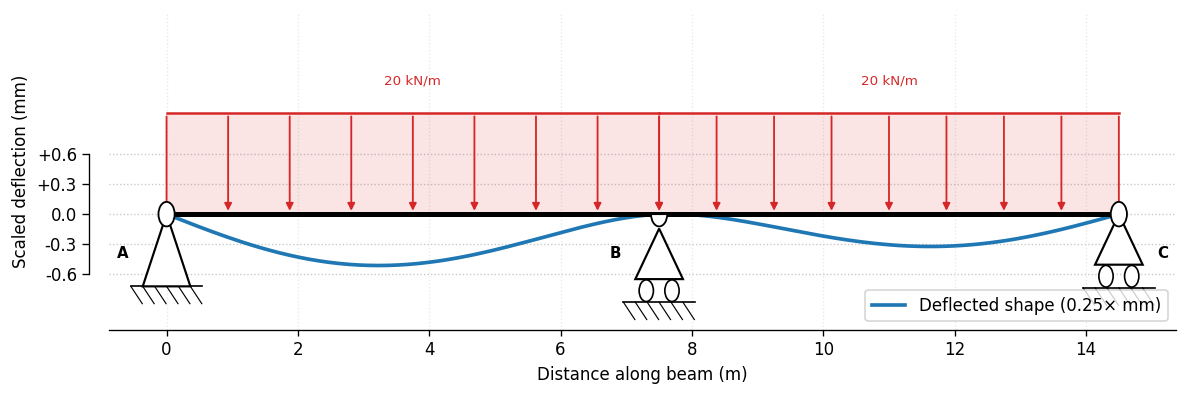

In [4]:
us = cba.get_units()
x_defl, d_defl = ba.beam_results.deflection_curve()
deflection_scale = 0.25  # visual scale, chosen to sit below the support glyphs
y_defl = d_defl * us.disp_scale * deflection_scale

fig, ax = plt.subplots(figsize=(10, 3.4))
ba.plot_beam(ax=ax, dimensions=False, equal_aspect=False)

ax.plot(
    x_defl,
    y_defl,
    color="tab:blue",
    lw=2.2,
    label=f"Deflected shape ({deflection_scale:g}× {us.disp_label})",
)
ax.set_xlabel(us.distance_axis)
ax.set_ylabel(f"Scaled deflection ({us.disp_label})")
ax.grid(True, which="both", linestyle=":", color="0.78")

# Keep the x- and y-axes for scale, but avoid drawing a full enclosing box.
# The structure schematic hides y ticks by default; restore them and offset the
# y-axis slightly left so the scale does not crowd the support glyphs.
ax.spines["left"].set_visible(True)
ax.spines["left"].set_position(("outward", 12))
max_deflection = max(abs(y_defl.min()), abs(y_defl.max()))
# Choose a simple symmetric scale that adapts to the plotted deflection.
target_step = max_deflection / 2
base_step = 10 ** np.floor(np.log10(target_step)) if target_step > 0 else 1.0
for multiple in (1, 1.5, 2, 2.5, 3, 4, 5, 7.5, 10):
    tick_step = multiple * base_step
    if tick_step >= target_step:
        break
scale_ticks = tick_step * np.arange(-2, 3)
ax.set_yticks(scale_ticks)
ax.set_yticklabels([f"{tick:+.2g}" if abs(tick) > 1e-12 else "0.0" for tick in scale_ticks])
ax.spines["left"].set_bounds(scale_ticks[0], scale_ticks[-1])
ax.tick_params(axis="y", left=True, labelleft=True, length=4)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## Interactive Plotly backend

PyCBA's result diagrams and envelopes can be drawn with an optional [Plotly](https://plotly.com/python/) backend, giving interactive figures you can pan, zoom and — most usefully — **hover over to read the value at any section**.

Plotly is an *optional* dependency; the default backend remains matplotlib, so nothing changes unless you ask for it. Install it with:

```bash
pip install pycba[plotly]      # or: pip install plotly
```

Choose the backend per call with `backend="plotly"`, or globally with `cba.set_backend("plotly")`.

In [5]:
def show_plotly(fig):
    # Embed the interactive figure (plotly.js from the CDN) so it renders both
    # here and in the documentation. In your own notebook, returning `fig` or
    # calling `fig.show()` is enough.
    return HTML(fig.to_html(include_plotlyjs="cdn", full_html=False))

### Combined result diagrams

Analyse a two-span beam, then plot the bending-moment, shear-force and deflection diagrams together. Because the three panels share the x-axis, a single hover reports all three load effects at the same section. The bending moment keeps PyCBA's sagging-positive convention, plotted below the axis.

In [6]:
interactive_ba = cba.BeamAnalysis(L=[6, 8], EI=30e3, R=[-1, 0, -1, 0, -1, 0])
interactive_ba.add_udl(i_member=1, w=20)
interactive_ba.add_pl(i_member=2, p=50, a=4)
interactive_ba.analyze()

show_plotly(interactive_ba.plot_results(backend="plotly"))

### A single diagram

Each diagram is also available on its own — `plot_bmd`, `plot_sfd` and `plot_dsd` — and they all take the same `backend=` argument.

In [7]:
show_plotly(interactive_ba.plot_bmd(backend="plotly"))

### Moving-load envelopes

`Envelopes.plot()` also supports the Plotly backend. Run a vehicle across the beam and hover over the shaded max/min band to read the governing moment or shear at any section.

In [8]:
bridge_analysis = cba.BridgeAnalysis(interactive_ba)
bridge_analysis.add_vehicle(axle_spacings=np.array([1.5]), axle_weights=np.array([60, 60]))
env = bridge_analysis.run_vehicle(0.25)

show_plotly(env.plot(backend="plotly"))

### Setting the backend globally

`cba.set_backend("plotly")` makes subsequent result plots interactive with no per-call argument; `cba.set_backend("matplotlib")` restores the default, and `cba.get_backend()` reports the current setting.

In [9]:
cba.set_backend("plotly")
fig = interactive_ba.plot_sfd()   # interactive — no backend= needed
cba.set_backend("matplotlib")     # restore the default
show_plotly(fig)